# 03 PyQSAR3 Modeling

## Step 3.1: Native PyQSAR3 Pre-Filtering

This notebook restarts Phase 3 from the raw Mordred descriptor outputs and performs only pre-filtering. Native PyQSAR3 filtering tools are used for non-numeric, missing, infinite, and zero-variance descriptor cleanup. A train-set-only Pearson correlation pass is then applied because the installed PyQSAR3 package does not expose a dedicated high-correlation pre-filter function.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from pyqsar import data_tools as dt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_IN = PROJECT_ROOT / "data" / "features" / "mordred_train.csv"
TEST_IN = PROJECT_ROOT / "data" / "features" / "mordred_test.csv"
TRAIN_OUT = PROJECT_ROOT / "data" / "features" / "filtered_train_pyqsar3.csv"
TEST_OUT = PROJECT_ROOT / "data" / "features" / "filtered_test_pyqsar3.csv"

ID_COLUMNS = ["SMILES", "logKoc"]
CORRELATION_THRESHOLD = 0.90

assert TRAIN_IN.exists(), f"Missing input file: {TRAIN_IN}"
assert TEST_IN.exists(), f"Missing input file: {TEST_IN}"


## Load Raw Mordred Descriptor Tables

The Phase 2 outputs are loaded as fixed inputs. `SMILES` and `logKoc` are preserved while descriptor columns are filtered strictly from Training-set decisions.

In [2]:
train_raw = pd.read_csv(TRAIN_IN)
test_raw = pd.read_csv(TEST_IN)

assert train_raw.shape == (514, 1615), f"Unexpected train shape: {train_raw.shape}"
assert test_raw.shape == (128, 1615), f"Unexpected test shape: {test_raw.shape}"
assert list(train_raw.columns) == list(test_raw.columns), "Train/Test raw schemas differ"
assert train_raw.columns[:2].tolist() == ID_COLUMNS, "Expected SMILES/logKoc as the first columns"

train_meta = train_raw[ID_COLUMNS].copy()
test_meta = test_raw[ID_COLUMNS].copy()
X_train_raw = train_raw.drop(columns=ID_COLUMNS).copy()
X_test_raw = test_raw.drop(columns=ID_COLUMNS).copy()

print(f"Raw Train shape: {train_raw.shape}")
print(f"Raw Test shape: {test_raw.shape}")
print(f"Raw descriptor count: {X_train_raw.shape[1]}")


Raw Train shape: (514, 1615)
Raw Test shape: (128, 1615)
Raw descriptor count: 1613


## Native PyQSAR3 Filtering Helpers

PyQSAR3's `FilteringTools` expects the first three columns to be `ID`, endpoint, and SMILES, with descriptors starting at column index 3. The helper below adapts the existing `SMILES`/`logKoc` tables to that native layout, calls the native methods, and returns the selected descriptor columns for application to both Train and Test sets.

In [3]:
def to_pyqsar_format(meta: pd.DataFrame, X: pd.DataFrame) -> pd.DataFrame:
    return pd.concat(
        [
            pd.Series(np.arange(1, len(meta) + 1), name="ID"),
            meta["logKoc"].rename("EP").reset_index(drop=True),
            meta["SMILES"].rename("SMI").reset_index(drop=True),
            X.reset_index(drop=True),
        ],
        axis=1,
    )


def make_filtering_tool(pyqsar_df: pd.DataFrame):
    tool = dt.FilteringTools.__new__(dt.FilteringTools)
    tool.X_data = pyqsar_df.copy()
    tool.X_data_ = pyqsar_df.copy()
    tool.nan_list = []
    tool.novar_list = []
    tool.inf_list = []
    tool.etc_list = []
    tool.etc_val_list = []
    return tool


def selected_descriptors_from_pyqsar_frame(pyqsar_df: pd.DataFrame) -> list[str]:
    return pyqsar_df.columns[3:].tolist()


## Native PyQSAR3 Non-Numeric, Missing, Infinite, and Zero-Variance Filters

The library-native `dt.NonNumricFilter` mirrors the project example and removes non-numeric/all-zero descriptors. `FilteringTools.rm_nan`, `rm_inf`, and `rm_novar` are then fitted on the Training set only. The resulting Training descriptor list is applied to the Test set unchanged.

In [4]:
# Native pyqsar3 example filter: numeric and non-all-zero descriptors.
X_train_numeric, numeric_descriptors = dt.NonNumricFilter(X_train_raw)
X_test_numeric = X_test_raw[numeric_descriptors].copy()

pyqsar_train_numeric = to_pyqsar_format(train_meta, X_train_numeric)
filter_tool = make_filtering_tool(pyqsar_train_numeric)

after_nan = filter_tool.rm_nan()
after_inf = filter_tool.rm_inf()
after_novar = filter_tool.rm_novar()

native_filtered_descriptors = selected_descriptors_from_pyqsar_frame(after_novar)
X_train_native = X_train_raw[native_filtered_descriptors].copy()
X_test_native = X_test_raw[native_filtered_descriptors].copy()

native_removed = X_train_raw.shape[1] - len(native_filtered_descriptors)

print(f"Descriptors after native PyQSAR3 filters: {len(native_filtered_descriptors)}")
print(f"Descriptors removed by native PyQSAR3 filters: {native_removed}")
print(f"Train native-filtered descriptor shape: {X_train_native.shape}")
print(f"Test native-filtered descriptor shape: {X_test_native.shape}")

assert X_train_native.shape[1] == X_test_native.shape[1], "Train/Test native-filtered feature counts differ"
assert list(X_train_native.columns) == list(X_test_native.columns), "Train/Test native-filtered schemas differ"
assert not X_train_native.isna().any().any(), "Training NaNs remain after native rm_nan"
assert np.isfinite(X_train_native.to_numpy(dtype=float)).all(), "Training Inf values remain after native rm_inf"


Start :  (514, 1613)
Filterd : (514, 1446)
NaN       : 491


Inf       : 0


No Var    : 0
Descriptors after native PyQSAR3 filters: 955
Descriptors removed by native PyQSAR3 filters: 658
Train native-filtered descriptor shape: (514, 955)
Test native-filtered descriptor shape: (128, 955)


## Train-Set Pearson High-Correlation Filter

The installed PyQSAR3 package provides correlation visualization utilities but no dedicated high-correlation pre-filter method. To complete the required pre-filtering while preserving the no-leakage rule, Pearson correlations are computed strictly on the Training descriptors that survived native PyQSAR3 filtering. The same dropped columns are then removed from the Test set.

In [5]:
corr_matrix = X_train_native.corr(method="pearson").abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlation_drop_columns = [
    column for column in upper_triangle.columns
    if (upper_triangle[column] > CORRELATION_THRESHOLD).any()
]

X_train_filtered = X_train_native.drop(columns=correlation_drop_columns)
X_test_filtered = X_test_native.drop(columns=correlation_drop_columns)

print(f"Correlation threshold: abs(r) > {CORRELATION_THRESHOLD}")
print(f"Highly correlated descriptors removed: {len(correlation_drop_columns)}")
print(f"Final descriptor count: {X_train_filtered.shape[1]}")

assert X_train_filtered.shape[1] == X_test_filtered.shape[1], "Train/Test final feature counts differ"
assert list(X_train_filtered.columns) == list(X_test_filtered.columns), "Train/Test final schemas differ"


Correlation threshold: abs(r) > 0.9
Highly correlated descriptors removed: 578
Final descriptor count: 377


## Save PyQSAR3-Filtered Outputs

The final outputs retain `SMILES`, `logKoc`, and the surviving descriptors. No Test-set statistics are used to fit any filter.

In [6]:
filtered_train = pd.concat(
    [train_meta.reset_index(drop=True), X_train_filtered.reset_index(drop=True)],
    axis=1,
)
filtered_test = pd.concat(
    [test_meta.reset_index(drop=True), X_test_filtered.reset_index(drop=True)],
    axis=1,
)

assert filtered_train.shape[0] == train_raw.shape[0], "Train row count changed"
assert filtered_test.shape[0] == test_raw.shape[0], "Test row count changed"
assert list(filtered_train.columns) == list(filtered_test.columns), "Filtered Train/Test schemas differ"

TRAIN_OUT.parent.mkdir(parents=True, exist_ok=True)
filtered_train.to_csv(TRAIN_OUT, index=False)
filtered_test.to_csv(TEST_OUT, index=False)

print(f"Saved Train output: {TRAIN_OUT}")
print(f"Saved Test output: {TEST_OUT}")
print(f"Final Train shape: {filtered_train.shape}")
print(f"Final Test shape: {filtered_test.shape}")


Saved Train output: /home/jun/Documents/qsar_modeling/data/features/filtered_train_pyqsar3.csv
Saved Test output: /home/jun/Documents/qsar_modeling/data/features/filtered_test_pyqsar3.csv
Final Train shape: (514, 379)
Final Test shape: (128, 379)


## Step 3.2: Native PyQSAR3 Feature Clustering

This corrected section performs native PyQSAR3 descriptor clustering for downstream GA/MC feature-selection engines. PyQSAR3 clusters descriptor columns, not compound rows, so the previous row-wise partition files are removed and the filtered training descriptor matrix remains the single source of truth.

In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from pyqsar import model_tools as mt

STEP32_ROOT = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()
if STEP32_ROOT.name == "notebooks":
    STEP32_ROOT = STEP32_ROOT.parent

FEATURE_DIR = STEP32_ROOT / "data" / "features"
FILTERED_TRAIN_PATH = FEATURE_DIR / "filtered_train_pyqsar3.csv"
FEATURE_CLUSTER_JSON = FEATURE_DIR / "feature_clusters_pyqsar3.json"
FEATURE_CLUSTER_STEM = FEATURE_DIR / "feature_clusters_pyqsar3"

ROW_WISE_TRACK_FILES = [
    FEATURE_DIR / "train_track_hierarchical_pyqsar3.csv",
    FEATURE_DIR / "train_track_kmeans_pyqsar3.csv",
    FEATURE_DIR / "train_track_som_pyqsar3.csv",
]

TARGET_FEATURE_CLUSTERS = 20
KMEANS_FEATURE_CLUSTERS = 20
SOM_MAP_SIZE = 5
SOM_RANDOM_SEED = 42

print(f"Feature directory: {FEATURE_DIR}")

Feature directory: /home/jun/Documents/qsar_modeling/data/features


### Roll Back Incorrect Row-Wise Track Outputs

The three row-partitioned training tables are not compatible with PyQSAR3 GA/MC selection, which expects feature-cluster assignments. This cell removes those obsolete artifacts if they exist.

In [8]:
deleted_row_track_files = []
for path in ROW_WISE_TRACK_FILES:
    if path.exists():
        path.unlink()
        deleted_row_track_files.append(str(path))

if deleted_row_track_files:
    print("Deleted obsolete row-wise track files:")
    for path in deleted_row_track_files:
        print(f"- {path}")
else:
    print("No obsolete row-wise track files were present.")

No obsolete row-wise track files were present.


### Load PyQSAR3-Filtered Descriptors

The filtered training table contains `SMILES`, `logKoc`, and 377 retained descriptors. The native K-Means and SOM feature cluster classes expect a PyQSAR-style table whose first three columns are metadata, so a compatibility table is created while preserving all descriptor columns for clustering.

In [9]:
train_filtered = pd.read_csv(FILTERED_TRAIN_PATH)
assert train_filtered.shape == (514, 379), f"Unexpected filtered train shape: {train_filtered.shape}"
assert {"SMILES", "logKoc"}.issubset(train_filtered.columns), "Required SMILES/logKoc columns missing."

ID_COLUMNS = ["SMILES", "logKoc"]
X_train = train_filtered.drop(columns=ID_COLUMNS).copy()
assert X_train.shape == (514, 377), f"Unexpected descriptor matrix shape: {X_train.shape}"
assert X_train.columns.is_unique, "Descriptor names must be unique before feature clustering."

pyqsar_metadata = pd.DataFrame({
    "Name": [f"train_{idx:04d}" for idx in range(len(train_filtered))],
    "Cid": np.arange(len(train_filtered)),
    "Smiles": train_filtered["SMILES"].astype(str),
})
pyqsar_feature_input = pd.concat(
    [pyqsar_metadata.reset_index(drop=True), X_train.reset_index(drop=True)],
    axis=1,
)

assert pyqsar_feature_input.shape == (514, 380), f"Unexpected PyQSAR-compatible shape: {pyqsar_feature_input.shape}"
print(f"Filtered train table: {train_filtered.shape}")
print(f"Descriptor matrix for feature clustering: {X_train.shape}")
print(f"PyQSAR-compatible feature table: {pyqsar_feature_input.shape}")

Filtered train table: (514, 379)
Descriptor matrix for feature clustering: (514, 377)
PyQSAR-compatible feature table: (514, 380)


### Helper Functions for Cluster Mapping

The JSON output stores a descriptor-to-cluster mapping for each native method, plus cluster counts for quick verification. The mapping is intentionally based only on the 377 descriptor columns.

In [10]:
def feature_assignment_mapping(feature_names, assignments):
    if len(feature_names) != len(assignments):
        raise ValueError(f"Feature/assignment length mismatch: {len(feature_names)} vs {len(assignments)}")
    return {feature: int(cluster) for feature, cluster in zip(feature_names, assignments)}


def cluster_count(mapping):
    return len(set(mapping.values()))


def cluster_size_summary(mapping):
    counts = {}
    for cluster in mapping.values():
        counts[str(cluster)] = counts.get(str(cluster), 0) + 1
    return dict(sorted(counts.items(), key=lambda item: int(item[0])))


def choose_hierarchical_cut(abs_corr, target_clusters=20, linkage_method="average"):
    linkage_matrix = mt.linkage(abs_corr, method=linkage_method)
    max_distance = float(linkage_matrix[:, 2].max())
    candidate_cuts = np.linspace(0.01, max_distance, 1000)
    best_cut = None
    best_count = None
    best_delta = None
    for cut in candidate_cuts:
        labels = mt.fcluster(linkage_matrix, cut, "distance") - 1
        count = len(np.unique(labels))
        delta = abs(count - target_clusters)
        if best_delta is None or delta < best_delta or (delta == best_delta and cut < best_cut):
            best_cut = float(cut)
            best_count = int(count)
            best_delta = int(delta)
    return best_cut, best_count

### Native PyQSAR3 Feature Clustering

Three native PyQSAR3 feature-clustering methods are applied: hierarchical clustering (`FeatureCluster`), K-Means (`FeatureCluster_KMeans`), and SOM (`FeatureCluster_Minisom`). The PyQSAR3 `data_name` stem is pointed into `data/features` so the native `.cluster` sidecar files are written with the rest of the feature artifacts.


 Cluster 0 ['ATS0Z', 'ATS2Z', 'ATS3Z', 'BCUTd-1h', 'SM1_DzZ', 'Xc-3d', 'Xc-4d', 'Xc-3dv', 'Xpc-4d', 'Xpc-4dv', 'ETA_shape_x', 'AETA_eta'] 
 Cluster 1 ['nBridgehead', 'ATSC3d', 'C3SP3', 'Xch-6d', 'Xc-5d', 'Xc-6d', 'Xc-5dv', 'NssssC', 'SssssC', 'PEOE_VSA5', 'n4Ring', 'n5Ring', 'nARing', 'n5ARing', 'nFARing', 'n10FARing', 'SRW05'] 
 Cluster 2 ['nN', 'ATSC2c', 'ATSC3c', 'ATSC4c', 'ATSC5dv', 'ATSC5se', 'AATSC2c', 'MATS1c', 'MATS2c', 'NssNH', 'NaaN', 'PEOE_VSA12', 'SMR_VSA3', 'SlogP_VSA1', 'nHRing', 'n6HRing', 'naHRing'] 
 Cluster 3 ['nAcid', 'nBase', 'VR1_A', 'nBr', 'ATSC7c', 'ATSC8c', 'ATSC4dv', 'ATSC6dv', 'ATSC4d', 'ATSC6d', 'ATSC7d', 'ATSC8d', 'ATSC3s', 'ATSC3Z', 'ATSC4Z', 'ATSC5Z', 'ATSC6Z', 'ATSC7Z', 'ATSC8Z', 'ATSC3v', 'ATSC4v', 'ATSC5v', 'ATSC6v', 'ATSC7v', 'ATSC8v', 'ATSC1se', 'ATSC3se', 'ATSC3p', 'ATSC4p', 'ATSC5p', 'ATSC6p', 'ATSC7p', 'ATSC8p', 'ATSC4i', 'ATSC5i', 'ATSC6i', 'ATSC7i', 'ATSC8i', 'AATSC1se', 'MATS1s', 'GATS2c', 'GATS1se', 'GATS2i', 'nBondsT', 'C2SP1', 'C1SP2', 'C4SP


 Cluster 0 ['ABC', 'nAcid', 'nBase', 'SpMax_A', 'SpMAD_A', 'nAromAtom', 'nAtom', 'nBridgehead', 'nHetero', 'nN', 'nO', 'nS', 'nP', 'nF', 'nCl', 'nBr', 'ATS7dv', 'AATS0dv', 'AATS0d', 'AATS0s', 'AATS1s', 'AATS0Z', 'AATS2Z', 'AATS0se', 'ATSC0c', 'ATSC1c', 'ATSC2c', 'ATSC3c', 'ATSC4c', 'ATSC5c', 'ATSC6c', 'ATSC7c', 'ATSC8c', 'ATSC1dv', 'ATSC2dv', 'ATSC3dv', 'ATSC4dv', 'ATSC5dv', 'ATSC6dv', 'ATSC7dv', 'ATSC8dv', 'ATSC1d', 'ATSC2d', 'ATSC3d', 'ATSC4d', 'ATSC5d', 'ATSC6d', 'ATSC7d', 'ATSC8d', 'ATSC1s', 'ATSC2s', 'ATSC3s', 'ATSC4s', 'ATSC5s', 'ATSC6s', 'ATSC7s', 'ATSC8s', 'ATSC1Z', 'ATSC2Z', 'ATSC4Z', 'ATSC7Z', 'ATSC8Z', 'ATSC1v', 'ATSC0se', 'ATSC1se', 'ATSC2se', 'ATSC3se', 'ATSC4se', 'ATSC5se', 'ATSC6se', 'ATSC7se', 'ATSC8se', 'ATSC0p', 'ATSC1p', 'ATSC2p', 'ATSC3p', 'ATSC4p', 'ATSC5p', 'ATSC6p', 'ATSC7p', 'ATSC8p', 'ATSC0i', 'ATSC1i', 'ATSC2i', 'ATSC3i', 'ATSC4i', 'ATSC5i', 'ATSC6i', 'ATSC7i', 'ATSC8i', 'AATSC0c', 'AATSC1c', 'AATSC2c', 'AATSC0dv', 'AATSC1dv', 'AATSC0d', 'AATSC1d', 'AATSC2d',

Quantization Error : 465.3185846965222

 Cluster 0 ['ATSC5dv', 'ATSC5s', 'ATSC5Z'] 
 Cluster 1 ['nAtom', 'ATSC1dv', 'BCUTv-1h', 'PEOE_VSA6', 'PEOE_VSA7'] 
 Cluster 2 ['EState_VSA5', 'EState_VSA8'] 
 Cluster 3 ['ATSC3dv', 'ATSC4dv'] 
 Cluster 4 ['ATSC5v'] 
 Cluster 5 ['ATSC2dv', 'ATSC2s', 'ATSC6s'] 
 Cluster 6 ['AATSC0Z', 'MIC0'] 
 Cluster 7 ['ATSC8dv', 'ATSC8s'] 
 Cluster 8 ['ABC', 'nAromAtom', 'AATS0dv', 'AATS0se', 'ATSC0p', 'BCUTs-1h', 'BCUTZ-1h', 'BCUTv-1l', 'BCUTi-1h', 'BCUTi-1l', 'PEOE_VSA1', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA5', 'SMR_VSA6', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA5', 'EState_VSA1', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA6', 'EState_VSA7', 'VSA_EState1', 'VSA_EState2'] 
 Cluster 9 ['ATSC6Z', 'ATSC6v'] 
 Cluster 10 ['ATSC1Z'] 
 Cluster 11 ['ATSC6dv', 'ATSC7dv', 'ATSC7s'] 
 Cluster 12 ['ATSC4Z', 'ATSC4v'] 
 Cluster 13 ['ATS0dv', 'AATS0v', 'AATS0i', 'AATS1i', 'AATS2i'] 
 Cluster 14 ['ATSC7Z', 'ATSC7v'] 
 Cluster 15 ['nAcid', 'nBase', 'SpMax_A', 'SpMAD_

Native PyQSAR3 feature clustering complete.
Hierarchical distance cut selected: 3.3209 (estimated clusters: 20)
Hierarchical: 20 feature clusters
KMeans: 20 feature clusters
SOM: 25 feature clusters


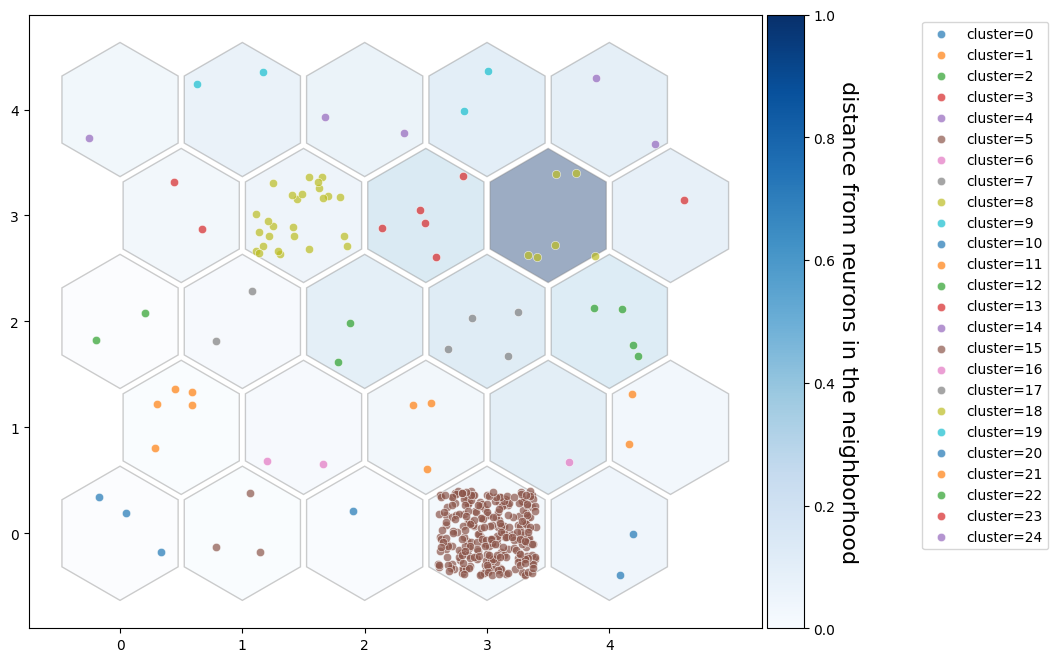

In [11]:
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
mt.ds.data_name = str(FEATURE_CLUSTER_STEM)

# Track 1: Hierarchical descriptor clustering. FeatureCluster uses a distance cut,
# so choose the cut closest to the target cluster count, then call the native method.
hierarchical_cut, estimated_hierarchical_clusters = choose_hierarchical_cut(
    abs(X_train.corr()),
    target_clusters=TARGET_FEATURE_CLUSTERS,
    linkage_method="average",
)
hierarchical_clusterer = mt.FeatureCluster(X_train)
hierarchical_assignments = hierarchical_clusterer.set_cluster("average", hierarchical_cut)
hierarchical_mapping = feature_assignment_mapping(X_train.columns.tolist(), hierarchical_assignments)

# Track 2: Native PyQSAR3 K-Means descriptor clustering.
kmeans_clusterer = mt.FeatureCluster_KMeans(
    pyqsar_feature_input,
    n_cluster=KMEANS_FEATURE_CLUSTERS,
    random_state=42,
    init="k-means++",
    algorithm="auto",
)
kmeans_assignments = kmeans_clusterer.set_cluster()
kmeans_mapping = feature_assignment_mapping(X_train.columns.tolist(), kmeans_assignments)

# Track 3: Native PyQSAR3 SOM descriptor clustering. A 5 x 5 map yields up to 25 bins,
# with empty bins compacted internally by PyQSAR3.
som_clusterer = mt.FeatureCluster_Minisom(
    pyqsar_feature_input,
    error="qe",
    random_seed=SOM_RANDOM_SEED,
    train=1000,
    neighborhood_function="gaussian",
    topology="hexagonal",
)
som_assignments = som_clusterer.set_cluster(
    map_n=SOM_MAP_SIZE,
    sigma=0.5,
    lr=0.5,
    init="random",
)
som_mapping = feature_assignment_mapping(X_train.columns.tolist(), som_assignments)

# PyQSAR3 writes a SOM diagnostic PNG to the execution directory; remove it so this
# step leaves only the requested notebook and feature-clustering artifacts.
for generated_plot in [
    STEP32_ROOT / "som_seed_qe_hexagonal.png",
    STEP32_ROOT / "notebooks" / "som_seed_qe_hexagonal.png",
]:
    if generated_plot.exists():
        generated_plot.unlink()

feature_cluster_mappings = {
    "Hierarchical": hierarchical_mapping,
    "KMeans": kmeans_mapping,
    "SOM": som_mapping,
}

feature_cluster_counts = {
    method: cluster_count(mapping)
    for method, mapping in feature_cluster_mappings.items()
}

print("Native PyQSAR3 feature clustering complete.")
print(f"Hierarchical distance cut selected: {hierarchical_cut:.4f} (estimated clusters: {estimated_hierarchical_clusters})")
for method, count in feature_cluster_counts.items():
    print(f"{method}: {count} feature clusters")

### Save Feature Cluster Mapping

The JSON mapping records each descriptor's assigned feature cluster for the three native PyQSAR3 clustering tracks. This is a records artifact; Step 3.3 can also consume the live `cluster_info` / assignment objects in this notebook.

In [12]:
feature_cluster_payload = {
    "source_file": str(FILTERED_TRAIN_PATH),
    "n_descriptors": int(X_train.shape[1]),
    "parameters": {
        "target_hierarchical_clusters": TARGET_FEATURE_CLUSTERS,
        "hierarchical_linkage": "average",
        "hierarchical_distance_cut": hierarchical_cut,
        "kmeans_n_cluster": KMEANS_FEATURE_CLUSTERS,
        "som_map_size": SOM_MAP_SIZE,
        "som_sigma": 0.5,
        "som_learning_rate": 0.5,
        "som_random_seed": SOM_RANDOM_SEED,
    },
    "cluster_counts": feature_cluster_counts,
    "cluster_sizes": {
        method: cluster_size_summary(mapping)
        for method, mapping in feature_cluster_mappings.items()
    },
    "mappings": feature_cluster_mappings,
}

with FEATURE_CLUSTER_JSON.open("w", encoding="utf-8") as handle:
    json.dump(feature_cluster_payload, handle, indent=2)

assert FEATURE_CLUSTER_JSON.exists(), f"Missing output JSON: {FEATURE_CLUSTER_JSON}"
assert set(feature_cluster_payload["mappings"].keys()) == {"Hierarchical", "KMeans", "SOM"}
for method, mapping in feature_cluster_payload["mappings"].items():
    assert len(mapping) == 377, f"{method} mapping does not cover all descriptors."

print(f"Saved feature cluster mapping: {FEATURE_CLUSTER_JSON}")
for method, sizes in feature_cluster_payload["cluster_sizes"].items():
    print(f"{method} cluster sizes: {sizes}")

Saved feature cluster mapping: /home/jun/Documents/qsar_modeling/data/features/feature_clusters_pyqsar3.json
Hierarchical cluster sizes: {'0': 12, '1': 17, '2': 17, '3': 111, '4': 12, '5': 5, '6': 9, '7': 19, '8': 14, '9': 10, '10': 5, '11': 8, '12': 29, '13': 38, '14': 20, '15': 11, '16': 14, '17': 13, '18': 4, '19': 9}
KMeans cluster sizes: {'0': 352, '1': 1, '2': 1, '3': 1, '4': 1, '5': 1, '6': 1, '7': 1, '8': 1, '9': 1, '10': 1, '11': 7, '12': 1, '13': 1, '14': 1, '15': 1, '16': 1, '17': 1, '18': 1, '19': 1}
SOM cluster sizes: {'0': 3, '1': 5, '2': 2, '3': 2, '4': 1, '5': 3, '6': 2, '7': 2, '8': 26, '9': 2, '10': 1, '11': 3, '12': 2, '13': 5, '14': 2, '15': 292, '16': 1, '17': 4, '18': 6, '19': 2, '20': 2, '21': 2, '22': 4, '23': 1, '24': 2}


## Step 3.3: 8-Descriptor All-in-One Execution Matrix

This section regenerates the 12-model PyQSAR3 matrix under the corrected benchmark constraint: every GA/MC feature-selection run is forced to select exactly **8 descriptors**. Each model is evaluated immediately on training fit, 5-fold out-of-fold cross-validation, and the external Test set using the extended OECD-style metrics framework.

In [13]:
import builtins
import contextlib
import json
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

from pyqsar import model_tools as mt
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

STEP33_ROOT = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()
if STEP33_ROOT.name == "notebooks":
    STEP33_ROOT = STEP33_ROOT.parent

FEATURE_DIR = STEP33_ROOT / "data" / "features"
FILTERED_TRAIN_PATH = FEATURE_DIR / "filtered_train_pyqsar3.csv"
FILTERED_TEST_PATH = FEATURE_DIR / "filtered_test_pyqsar3.csv"
FEATURE_CLUSTER_JSON = FEATURE_DIR / "feature_clusters_pyqsar3.json"
EXTENDED_METRICS_OUT = FEATURE_DIR / "12_model_extended_metrics.csv"
SELECTED_FEATURES_8_OUT = FEATURE_DIR / "final_selected_features_8vars.json"
TEST_PREDICTIONS_8_OUT = FEATURE_DIR / "test_predictions_8vars.csv"

CLUSTER_FILES = {
    "Hierarchical": "feature_clusters_pyqsar3_hierarchical.cluster",
    "KMeans": "feature_clusters_pyqsar3_kmeans.cluster",
    "SOM": "feature_clusters_pyqsar3_som.cluster",
}
SELECTORS = ["GA", "MC"]
REGRESSORS = ["MLR", "PLS"]
N_SELECTED_FEATURES = 8
PLS_COMPONENTS = 3
GA_POPULATION = 80
GA_GENERATIONS = 80
MC_LEARNING = 120
MC_BANK = 120
RANDOM_STATE = 42

print(f"Feature directory: {FEATURE_DIR}")
print(f"8-descriptor selected-feature output: {SELECTED_FEATURES_8_OUT}")

Feature directory: /home/jun/Documents/qsar_modeling/data/features
8-descriptor selected-feature output: /home/jun/Documents/qsar_modeling/data/features/final_selected_features_8vars.json


### Custom Metrics

The helper functions below implement the requested metrics explicitly. `q2_ext_f2` is equivalent to the standard external Test-set `r2_score`, while `q2_ext_f1` and `q2_ext_f3` use the training-set response distribution in their denominators as specified.

In [14]:
def concordance_correlation_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    if y_true.size != y_pred.size:
        raise ValueError("CCC requires vectors of equal length.")
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    std_true = np.std(y_true, ddof=0)
    std_pred = np.std(y_pred, ddof=0)
    if std_true == 0 or std_pred == 0:
        return np.nan
    rho = np.corrcoef(y_true, y_pred)[0, 1]
    numerator = 2 * rho * std_true * std_pred
    denominator = std_true**2 + std_pred**2 + (mean_true - mean_pred)**2
    return float(numerator / denominator)


def q2_ext_f1(y_ext, y_pred_ext, y_train):
    y_ext = np.asarray(y_ext, dtype=float).reshape(-1)
    y_pred_ext = np.asarray(y_pred_ext, dtype=float).reshape(-1)
    y_train = np.asarray(y_train, dtype=float).reshape(-1)
    numerator = np.sum((y_ext - y_pred_ext) ** 2)
    denominator = np.sum((y_ext - np.mean(y_train)) ** 2)
    return float(1 - numerator / denominator)


def q2_ext_f2(y_ext, y_pred_ext):
    return float(r2_score(y_ext, y_pred_ext))


def q2_ext_f3(y_ext, y_pred_ext, y_train):
    y_ext = np.asarray(y_ext, dtype=float).reshape(-1)
    y_pred_ext = np.asarray(y_pred_ext, dtype=float).reshape(-1)
    y_train = np.asarray(y_train, dtype=float).reshape(-1)
    numerator = np.sum((y_ext - y_pred_ext) ** 2) / len(y_ext)
    denominator = np.sum((y_train - np.mean(y_train)) ** 2) / len(y_train)
    return float(1 - numerator / denominator)

### Load Filtered Train/Test Matrices and Feature Clusters

The training and test matrices already share the same train-fitted filtered descriptor schema. Feature-selection uses the Step 3.2 native PyQSAR3 `.cluster` sidecar files.

In [15]:
train_filtered = pd.read_csv(FILTERED_TRAIN_PATH)
test_filtered = pd.read_csv(FILTERED_TEST_PATH)

assert train_filtered.shape == (514, 379), f"Unexpected train shape: {train_filtered.shape}"
assert test_filtered.shape == (128, 379), f"Unexpected test shape: {test_filtered.shape}"
assert list(train_filtered.columns) == list(test_filtered.columns), "Train/Test schemas differ."

with FEATURE_CLUSTER_JSON.open("r", encoding="utf-8") as handle:
    feature_cluster_payload = json.load(handle)
assert feature_cluster_payload["n_descriptors"] == 377

for track, filename in CLUSTER_FILES.items():
    assert (FEATURE_DIR / filename).exists(), f"Missing cluster file for {track}: {filename}"

X_train = train_filtered.drop(columns=["SMILES", "logKoc"]).copy()
X_test = test_filtered.drop(columns=["SMILES", "logKoc"]).copy()
y_train = train_filtered["logKoc"].astype(float).to_numpy()
y_test = test_filtered["logKoc"].astype(float).to_numpy()
y_train_df = pd.DataFrame({"EP": y_train})

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Feature-cluster counts: {feature_cluster_payload['cluster_counts']}")

X_train: (514, 377)
X_test: (128, 377)
Feature-cluster counts: {'Hierarchical': 20, 'KMeans': 20, 'SOM': 25}


### Native PyQSAR3 Selection Wrapper

PyQSAR3's native GA/MC functions prompt interactively for the cluster file. This wrapper patches `input()` only for that prompt, sets a deterministic seed, and invokes the native selection engine with `component=8`.

In [16]:
@contextlib.contextmanager
def working_directory(path):
    previous = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(previous)


def cluster_file_index(cluster_filename):
    file_list = [file for file in os.listdir() if file.endswith(".cluster")]
    if cluster_filename not in file_list:
        raise FileNotFoundError(f"{cluster_filename} not found among {file_list}")
    return file_list.index(cluster_filename)


def run_native_pyqsar_selection(track, selector, regressor):
    cluster_filename = CLUSTER_FILES[track]
    with working_directory(FEATURE_DIR):
        selected_index = cluster_file_index(cluster_filename)
        original_input = builtins.input

        def patched_input(prompt=""):
            if "Clust Info File Index" in prompt:
                return str(selected_index)
            return ""

        builtins.input = patched_input
        try:
            mt.ds.data_name = str(FEATURE_DIR / f"step33_8vars_{track.lower()}_{selector.lower()}_{regressor}")
            random.seed(RANDOM_STATE)
            np.random.seed(RANDOM_STATE)
            try:
                mt.random.seed(RANDOM_STATE)
            except AttributeError:
                pass

            if selector == "GA":
                selected, population = mt.selection_ga(
                    X_train,
                    y_train_df,
                    model=regressor,
                    pop_info=None,
                    n_pop_size=GA_POPULATION,
                    N_generation=GA_GENERATIONS,
                    component=N_SELECTED_FEATURES,
                )
            elif selector == "MC":
                selected, population = mt.selection_mc(
                    X_train,
                    y_train_df,
                    model=regressor,
                    pop_info=None,
                    learning=MC_LEARNING,
                    bank=MC_BANK,
                    component=N_SELECTED_FEATURES,
                    pntinterval=max(20, MC_LEARNING),
                )
            else:
                raise ValueError(f"Unsupported selector: {selector}")
        finally:
            builtins.input = original_input

    selected_features = [str(feature) for feature in selected]
    if len(selected_features) != N_SELECTED_FEATURES:
        raise ValueError(f"{track}-{selector}-{regressor} selected {len(selected_features)} features, expected {N_SELECTED_FEATURES}.")
    missing = [feature for feature in selected_features if feature not in X_train.columns]
    if missing:
        raise ValueError(f"{track}-{selector}-{regressor} selected unknown descriptors: {missing}")
    return selected_features

### Model Evaluation Helpers

MLR and PLS are evaluated with a `MinMaxScaler` fitted inside each training or cross-validation fold. This mirrors the scaling convention used in PyQSAR3 examples while keeping all metric calculations explicit and reproducible.

In [17]:
def make_estimator(regressor, n_features):
    if regressor == "MLR":
        return LinearRegression()
    if regressor == "PLS":
        return PLSRegression(n_components=min(PLS_COMPONENTS, n_features))
    raise ValueError(f"Unsupported regressor: {regressor}")


def make_pipeline(regressor, n_features):
    return Pipeline([
        ("scale", MinMaxScaler()),
        ("model", make_estimator(regressor, n_features)),
    ])


def evaluate_model(selected_features, regressor):
    Xtr = X_train.loc[:, selected_features].astype(float).to_numpy()
    Xte = X_test.loc[:, selected_features].astype(float).to_numpy()

    model = make_pipeline(regressor, len(selected_features))
    model.fit(Xtr, y_train)
    train_pred = np.asarray(model.predict(Xtr)).reshape(-1)
    test_pred = np.asarray(model.predict(Xte)).reshape(-1)

    cv_pred = np.zeros_like(y_train, dtype=float)
    kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    for fold_train_idx, fold_valid_idx in kfold.split(Xtr):
        fold_model = make_pipeline(regressor, len(selected_features))
        fold_model.fit(Xtr[fold_train_idx], y_train[fold_train_idx])
        cv_pred[fold_valid_idx] = np.asarray(fold_model.predict(Xtr[fold_valid_idx])).reshape(-1)

    metrics = {
        "R2_train": float(r2_score(y_train, train_pred)),
        "CCC_tr": concordance_correlation_coefficient(y_train, train_pred),
        "RMSE_train": float(mean_squared_error(y_train, train_pred, squared=False)),
        "Q2_cv": float(r2_score(y_train, cv_pred)),
        "CCC_cv": concordance_correlation_coefficient(y_train, cv_pred),
        "RMSE_cv": float(mean_squared_error(y_train, cv_pred, squared=False)),
        "MAE_cv": float(mean_absolute_error(y_train, cv_pred)),
        "Q2_ext_F1": q2_ext_f1(y_test, test_pred, y_train),
        "Q2_ext_F2": q2_ext_f2(y_test, test_pred),
        "Q2_ext_F3": q2_ext_f3(y_test, test_pred, y_train),
        "CCC_ext": concordance_correlation_coefficient(y_test, test_pred),
        "RMSE_ext": float(mean_squared_error(y_test, test_pred, squared=False)),
        "MAE_ext": float(mean_absolute_error(y_test, test_pred)),
    }
    return train_pred, cv_pred, test_pred, metrics

### Execute the 8-Descriptor 12-Model Matrix

This loop runs all 3 clustering tracks x 2 selection engines x 2 regressors. The external Test predictions are saved for all 12 models, and the selected descriptor lists are preserved for downstream interpretation and optional model expansion.

In [18]:
matrix_records = []
all_model_selected_features = {}
test_predictions = test_filtered[["SMILES", "logKoc"]].copy()

for track in CLUSTER_FILES:
    for selector in SELECTORS:
        for regressor in REGRESSORS:
            model_id = f"{track}_{selector}_{regressor}"
            print(f"\n=== Running {model_id} with {N_SELECTED_FEATURES} descriptors ===")
            selected_features = run_native_pyqsar_selection(track, selector, regressor)
            _, _, test_pred, metrics = evaluate_model(selected_features, regressor)

            all_model_selected_features[model_id] = selected_features
            test_predictions[f"Pred_{model_id}"] = test_pred

            record = {
                "Model_ID": model_id,
                "Track": track,
                "Selector": selector,
                "Regressor": regressor,
                "Cluster_File": CLUSTER_FILES[track],
                "N_Selected_Features": len(selected_features),
                "Selected_Features": ";".join(selected_features),
            }
            record.update(metrics)
            matrix_records.append(record)

extended_metrics = pd.DataFrame(matrix_records).sort_values("Q2_ext_F2", ascending=False).reset_index(drop=True)

assert extended_metrics.shape[0] == 12, f"Expected 12 models, found {extended_metrics.shape[0]}"
assert test_predictions.shape == (128, 14), f"Unexpected test prediction shape: {test_predictions.shape}"
assert (extended_metrics["N_Selected_Features"] == N_SELECTED_FEATURES).all(), "Not all models selected exactly 8 features."

extended_metrics.to_csv(EXTENDED_METRICS_OUT, index=False)
test_predictions.to_csv(TEST_PREDICTIONS_8_OUT, index=False)

print(f"Saved extended metrics: {EXTENDED_METRICS_OUT}")
print(f"Saved test predictions: {TEST_PREDICTIONS_8_OUT}")
display(extended_metrics)


=== Running Hierarchical_GA_MLR with 8 descriptors ===
MLR
Index   File Name
0       feature_clusters_pyqsar3_hierarchical.cluster
1       feature_clusters_pyqsar3_kmeans.cluster
2       feature_clusters_pyqsar3_som.cluster


feature_clusters_pyqsar3_hierarchical.cluster    file selected

---------------  Initialization  ---------------


  0%|          | 0/80 [00:00<?, ?it/s]

  0.585781   0.761511   2.848059% 
Generation        RMSD        R2      Portion
         1 : 

  0.585781   0.761511   1.908162% 
         2 : 

  0.583054   0.763726   1.365107% 
         3 : 

...

  0%|          | 0/120 [00:00<?, ?it/s]

    120 => 13:14:22 [ 0.8157, 0.5150] ['ABC', 'ATSC3s', 'BCUTs-1h', 'EState_VSA5', 'EState_VSA7', 'FilterItLogS', 'GATS1i', 'PEOE_VSA6']
R2       :  0.8157
RMSE     :  0.5150
Cluster  : ['ABC', 'ATSC3s', 'BCUTs-1h', 'EState_VSA5', 'EState_VSA7', 'FilterItLogS', 'GATS1i', 'PEOE_VSA6']
Model's cluster info [8, 15, 8, 2, 8, 15, 15, 1]
/home/jun/Documents/qsar_modeling/data/features/step33_8vars_som_mc_MLR_mc_MLR_som.log  is saved!

=== Running SOM_MC_PLS with 8 descriptors ===
Start time :  13:14:22
Index   File Name
0       feature_clusters_pyqsar3_hierarchical.cluster
1       feature_clusters_pyqsar3_kmeans.cluster
2       feature_clusters_pyqsar3_som.cluster


feature_clusters_pyqsar3_som.cluster    file selected

PLS
                       R^2                  RMSE


  0%|          | 0/120 [00:00<?, ?it/s]

    120 => 13:14:45 [ 0.8163, 0.5141] ['ABC', 'ATSC2Z', 'ATSC3s', 'BCUTs-1h', 'EState_VSA5', 'FilterItLogS', 'GATS1i', 'VSA_EState1']
R2       :  0.8163
RMSE     :  0.5141
Cluster  : ['ABC', 'ATSC2Z', 'ATSC3s', 'BCUTs-1h', 'EState_VSA5', 'FilterItLogS', 'GATS1i', 'VSA_EState1']
Model's cluster info [8, 24, 15, 8, 2, 15, 15, 8]
/home/jun/Documents/qsar_modeling/data/features/step33_8vars_som_mc_PLS_mc_PLS_som.log  is saved!
Saved extended metrics: /home/jun/Documents/qsar_modeling/data/features/12_model_extended_metrics.csv
Saved test predictions: /home/jun/Documents/qsar_modeling/data/features/test_predictions_8vars.csv


,Model_ID,Track,Selector,Regressor,Cluster_File,N_Selected_Features,Selected_Features,R2_train,CCC_tr,RMSE_train,Q2_cv,CCC_cv,RMSE_cv,MAE_cv,Q2_ext_F1,Q2_ext_F2,Q2_ext_F3,CCC_ext,RMSE_ext,MAE_ext
0,Hierarchical_GA_PLS,Hierarchical,GA,PLS,feature_clusters_pyqsar3_hierarchical.cluster,8,ABC;ATSC3s;BCUTs-1h;FilterItLogS;GATS1i;MATS1v...,0.816350,0.898890,0.514040,0.807286,0.894252,0.526572,0.417462,0.819976,0.819961,0.824682,0.909574,0.502244,0.405073
1,Hierarchical_GA_MLR,Hierarchical,GA,MLR,feature_clusters_pyqsar3_hierarchical.cluster,8,ABC;ATSC3s;BCUTs-1h;FilterItLogS;GATS1i;MATS1v...,0.816775,0.899148,0.513444,0.807124,0.894196,0.526792,0.418151,0.819748,0.819733,0.824460,0.909900,0.502562,0.404386
2,SOM_MC_PLS,SOM,MC,PLS,feature_clusters_pyqsar3_som.cluster,8,ABC;ATSC2Z;ATSC3s;BCUTs-1h;EState_VSA5;FilterI...,0.815863,0.898595,0.514721,0.803669,0.892734,0.531490,0.414283,0.817486,0.817471,0.822257,0.908353,0.505706,0.382805
3,Hierarchical_MC_PLS,Hierarchical,MC,PLS,feature_clusters_pyqsar3_hierarchical.cluster,8,ABC;BCUTs-1h;C1SP2;ETA_shape_y;FilterItLogS;Nd...,0.818294,0.900068,0.511312,0.811959,0.896633,0.520149,0.420112,0.816532,0.816517,0.821328,0.906940,0.507025,0.396826
4,Hierarchical_MC_MLR,Hierarchical,MC,MLR,feature_clusters_pyqsar3_hierarchical.cluster,8,ABC;BCUTs-1h;C1SP2;ETA_shape_y;FilterItLogS;Nd...,0.820182,0.901209,0.508648,0.811974,0.896656,0.520127,0.419998,0.814267,0.814252,0.819122,0.906043,0.510145,0.397140
5,KMeans_MC_MLR,KMeans,MC,MLR,feature_clusters_pyqsar3_kmeans.cluster,8,AATS2i;ATS0dv;ATS6Z;FilterItLogS;IC2;NdO;RNCG;...,0.799899,0.888827,0.536569,0.787166,0.881709,0.553378,0.441287,0.811955,0.811940,0.816871,0.901864,0.513310,0.395886
6,KMeans_GA_MLR,KMeans,GA,MLR,feature_clusters_pyqsar3_kmeans.cluster,8,ATS0dv;ATS1Z;ATS5Z;ATSC0se;ATSC3s;ETA_shape_y;...,0.783595,0.878669,0.558001,0.760978,0.867046,0.586435,0.462205,0.810462,0.810446,0.815417,0.898439,0.515344,0.413021
7,SOM_MC_MLR,SOM,MC,MLR,feature_clusters_pyqsar3_som.cluster,8,ABC;ATSC3s;BCUTs-1h;EState_VSA5;EState_VSA7;Fi...,0.815659,0.898472,0.515005,0.806598,0.893811,0.527511,0.410281,0.800784,0.800767,0.805991,0.899315,0.528338,0.406454
8,KMeans_GA_PLS,KMeans,GA,PLS,feature_clusters_pyqsar3_kmeans.cluster,8,ATS0dv;ATS1Z;ATS5Z;ATSC0se;ATSC3s;ETA_shape_y;...,0.768694,0.869222,0.576892,0.751181,0.861042,0.598333,0.468576,0.795683,0.795666,0.801024,0.890228,0.535059,0.420050
9,KMeans_MC_PLS,KMeans,MC,PLS,feature_clusters_pyqsar3_kmeans.cluster,8,ATS1Z;ATS3Z;ATSC3Z;ETA_shape_y;FilterItLogS;MA...,0.789885,0.882610,0.549832,0.774646,0.874989,0.569421,0.458416,0.793505,0.793488,0.798903,0.893517,0.537903,0.415934


### Save Consolidated 8-Descriptor Feature Lists

The primary JSON contains one 8-descriptor list for each of the six clustering plus selector paths. If the MLR and PLS coupled runs produce different lists for the same path, the list from the higher external `Q2_ext_F2` run is used as the consolidated path list; all 12 model-specific lists are retained under `all_model_selected_features`.

In [19]:
final_selected_features_8 = {}
selection_sources = {}

for track in CLUSTER_FILES:
    for selector in SELECTORS:
        path_key = f"{track}_{selector}"
        subset = extended_metrics[(extended_metrics["Track"] == track) & (extended_metrics["Selector"] == selector)]
        best_row = subset.sort_values("Q2_ext_F2", ascending=False).iloc[0]
        source_model_id = best_row["Model_ID"]
        final_selected_features_8[path_key] = all_model_selected_features[source_model_id]
        selection_sources[path_key] = {
            "source_model_id": source_model_id,
            "source_regressor": best_row["Regressor"],
            "Q2_ext_F2": float(best_row["Q2_ext_F2"]),
        }

feature_payload = {
    "n_selected_features": N_SELECTED_FEATURES,
    "selected_features": final_selected_features_8,
    "selection_sources": selection_sources,
    "all_model_selected_features": all_model_selected_features,
}

with SELECTED_FEATURES_8_OUT.open("w", encoding="utf-8") as handle:
    json.dump(feature_payload, handle, indent=2)

assert SELECTED_FEATURES_8_OUT.exists(), f"Missing selected feature output: {SELECTED_FEATURES_8_OUT}"
assert set(final_selected_features_8) == {
    "Hierarchical_GA", "Hierarchical_MC",
    "KMeans_GA", "KMeans_MC",
    "SOM_GA", "SOM_MC",
}
assert all(len(features) == N_SELECTED_FEATURES for features in final_selected_features_8.values())

print(f"Saved 8-descriptor selected features: {SELECTED_FEATURES_8_OUT}")
print("Top models by external Q2_ext_F2:")
display(extended_metrics.loc[:, [
    "Model_ID", "Q2_ext_F2", "Q2_ext_F1", "Q2_ext_F3", "CCC_ext",
    "RMSE_ext", "MAE_ext", "Q2_cv", "R2_train", "N_Selected_Features"
]])

Saved 8-descriptor selected features: /home/jun/Documents/qsar_modeling/data/features/final_selected_features_8vars.json
Top models by external Q2_ext_F2:


,Model_ID,Q2_ext_F2,Q2_ext_F1,Q2_ext_F3,CCC_ext,RMSE_ext,MAE_ext,Q2_cv,R2_train,N_Selected_Features
0,Hierarchical_GA_PLS,0.819961,0.819976,0.824682,0.909574,0.502244,0.405073,0.807286,0.816350,8
1,Hierarchical_GA_MLR,0.819733,0.819748,0.824460,0.909900,0.502562,0.404386,0.807124,0.816775,8
2,SOM_MC_PLS,0.817471,0.817486,0.822257,0.908353,0.505706,0.382805,0.803669,0.815863,8
3,Hierarchical_MC_PLS,0.816517,0.816532,0.821328,0.906940,0.507025,0.396826,0.811959,0.818294,8
4,Hierarchical_MC_MLR,0.814252,0.814267,0.819122,0.906043,0.510145,0.397140,0.811974,0.820182,8
5,KMeans_MC_MLR,0.811940,0.811955,0.816871,0.901864,0.513310,0.395886,0.787166,0.799899,8
6,KMeans_GA_MLR,0.810446,0.810462,0.815417,0.898439,0.515344,0.413021,0.760978,0.783595,8
7,SOM_MC_MLR,0.800767,0.800784,0.805991,0.899315,0.528338,0.406454,0.806598,0.815659,8
8,KMeans_GA_PLS,0.795666,0.795683,0.801024,0.890228,0.535059,0.420050,0.751181,0.768694,8
9,KMeans_MC_PLS,0.793488,0.793505,0.798903,0.893517,0.537903,0.415934,0.774646,0.789885,8
